# Investigating 4x8

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice

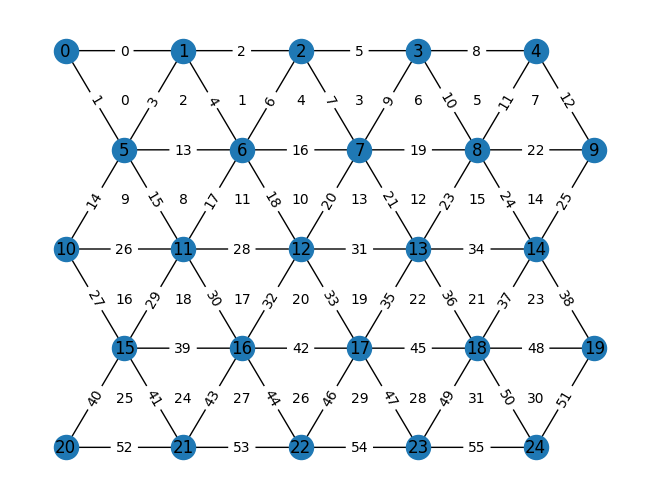

In [2]:
lattice = TriangularZ2Lattice((4, 8))
lattice.draw_graph();

## $\lambda = 0.8$

In [3]:
with h5py.File('/data/iiyama/2dz2/ground_4x8_l0.80_first1M.h5', 'r', libver='latest') as source:
    indices = source['indices'][()]
    sorted_probs = source['sorted_probs'][()]

In [4]:
sorted_probs[:10]

array([0.20858557, 0.02849898, 0.02849898, 0.02840148, 0.02840148,
       0.02760298, 0.02760298, 0.02568415, 0.02568415, 0.00449032])

In [5]:
indices[:10]

array([      0,  524288,    8192,  131072,    2048,   32768, 2097152,
           512,   65536,    1024])

In [6]:
nexc = np.bitwise_count(indices)

In [7]:
exc_probs_table = np.zeros((32, 2 ** 20))
exc_probs_table[nexc, np.arange(2 ** 20)] = sorted_probs
exc_probs = np.sum(exc_probs_table, axis=1)

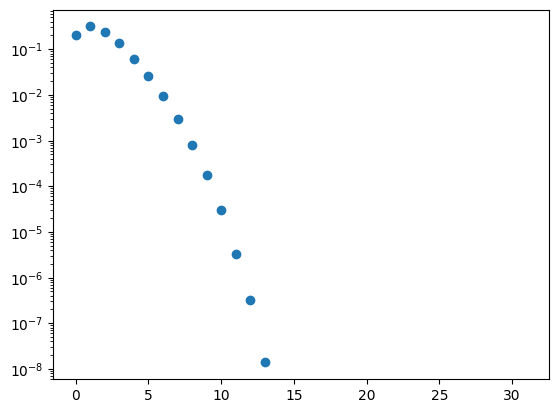

In [8]:
plt.scatter(np.arange(32), exc_probs)
plt.yscale('log')

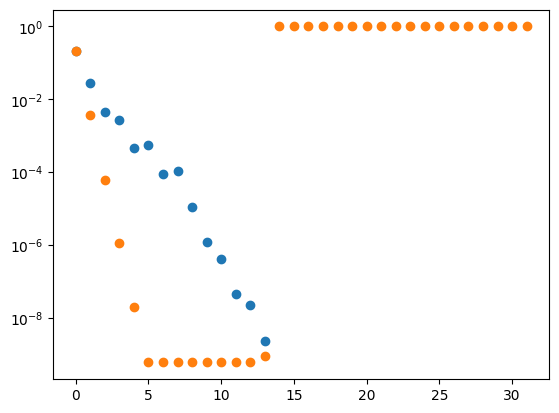

In [9]:
exc_probs_max = np.max(exc_probs_table, axis=1)
exc_probs_min = np.min(np.where(exc_probs_table == 0., 1., exc_probs_table), axis=1)
plt.scatter(np.arange(32), exc_probs_max)
plt.scatter(np.arange(32), exc_probs_min)
plt.yscale('log')

In [10]:
np.sum(sorted_probs)

np.float64(0.9994522739567817)

In [11]:
for idx in indices[:10]:
    print(np.nonzero((idx >> np.arange(32)) % 2))

(array([], dtype=int64),)
(array([19]),)
(array([13]),)
(array([17]),)
(array([11]),)
(array([15]),)
(array([21]),)
(array([9]),)
(array([16]),)
(array([10]),)


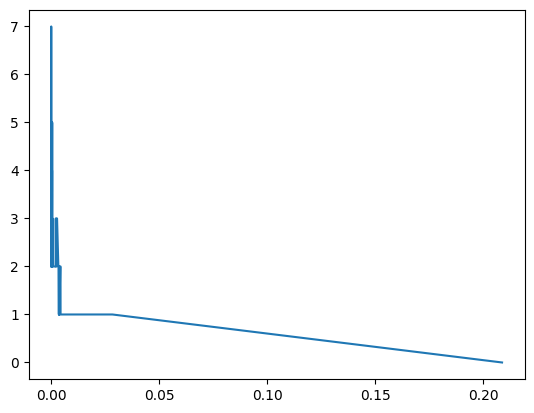

In [12]:
plt.plot(sorted_probs[:1000], nexc[:1000])

## $\lambda = 1.5$

In [13]:
with h5py.File('/data/iiyama/2dz2/ground_4x8_l1.50_first10M.h5', 'r', libver='latest') as source:
    indices = source['indices'][()]
    sorted_probs = source['sorted_probs'][()]

In [14]:
sorted_probs[:10]

array([0.00738106, 0.00269994, 0.00269994, 0.00267221, 0.00267221,
       0.00250773, 0.00250773, 0.00218764, 0.00218764, 0.00127215])

In [15]:
indices[:10]

array([      0,  524288,    8192,  131072,    2048,   32768, 2097152,
           512,   65536, 1703936])

In [16]:
nexc = np.bitwise_count(indices)

In [18]:
exc_probs_table = np.zeros((32, indices.shape[0]))
exc_probs_table[nexc, np.arange(indices.shape[0])] = sorted_probs
exc_probs = np.sum(exc_probs_table, axis=1)

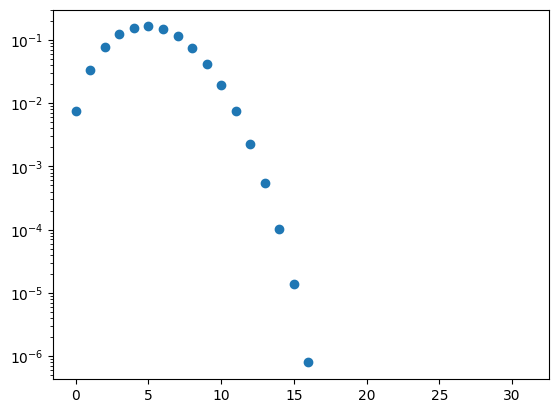

In [19]:
plt.scatter(np.arange(32), exc_probs)
plt.yscale('log')

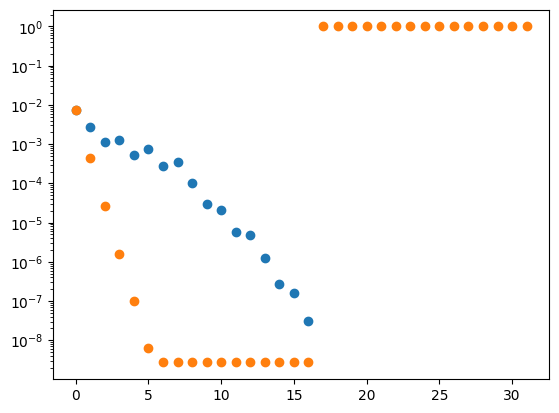

In [20]:
exc_probs_max = np.max(exc_probs_table, axis=1)
exc_probs_min = np.min(np.where(exc_probs_table == 0., 1., exc_probs_table), axis=1)
plt.scatter(np.arange(32), exc_probs_max)
plt.scatter(np.arange(32), exc_probs_min)
plt.yscale('log')

In [21]:
np.sum(sorted_probs)

np.float64(0.9634992015928344)

In [22]:
for idx in indices[:10]:
    print(np.nonzero((idx >> np.arange(32)) % 2))

(array([], dtype=int64),)
(array([19]),)
(array([13]),)
(array([17]),)
(array([11]),)
(array([15]),)
(array([21]),)
(array([9]),)
(array([16]),)
(array([17, 19, 20]),)


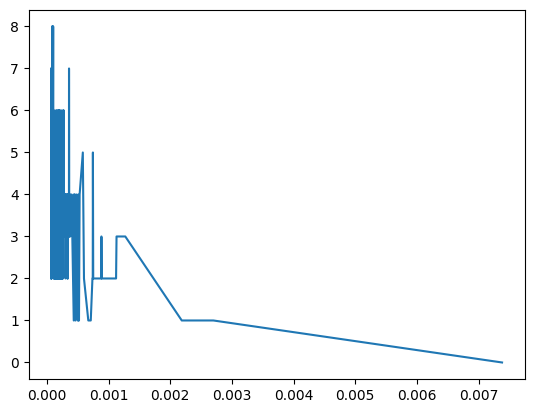

In [23]:
plt.plot(sorted_probs[:1000], nexc[:1000])